# Project 2: Neural Network and Deep Learning

1. **Part 1 (60%)** — 在 CIFAR-10 上训练自定义 CNN，并进行消融实验与可视化
2. **Part 2 (30%)** — VGG-A 与 VGG-A+BN 对比，分析 BN 对 loss landscape 的影响

## 0. 环境与通用工具

In [ ]:
import os
import random
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

plt.rcParams['figure.dpi'] = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

DATA_ROOT = './data'
FIGURES_DIR = './figures'
MODELS_DIR = './models'
ABLATION_MODELS_DIR = './models/ablation'
VGG_RESULTS_DIR = './vgg_results'
for d in [DATA_ROOT, FIGURES_DIR, MODELS_DIR, ABLATION_MODELS_DIR, VGG_RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

CIFAR10_CLASSES = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)


def compute_cifar10_stats(root=DATA_ROOT):
    """在 ToTensor 后、Normalize 前，统计训练集通道 mean/std。"""
    ds = datasets.CIFAR10(root=root, train=True, download=True, transform=transforms.ToTensor())
    loader = DataLoader(ds, batch_size=512, shuffle=False, num_workers=0)
    n_pixels = 0
    ch_sum = torch.zeros(3)
    ch_sq_sum = torch.zeros(3)
    for imgs, _ in loader:
        b, c, h, w = imgs.shape
        n = b * h * w
        ch_sum += imgs.sum(dim=(0, 2, 3))
        ch_sq_sum += (imgs ** 2).sum(dim=(0, 2, 3))
        n_pixels += n
    mean = ch_sum / n_pixels
    std = (ch_sq_sum / n_pixels - mean ** 2).clamp(min=0).sqrt()
    return tuple(mean.tolist()), tuple(std.tolist())

def set_random_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class EarlyStopper:
    """
    提前停止
    验证集准确率连续若干epoch无提升则提前停止。
    """
    def __init__(self, patience=8, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_acc = float('-inf')
        self.wait = 0
        self.should_stop = False

    def step(self, val_acc):
        if val_acc - self.best_acc > self.min_delta:
            self.best_acc = val_acc
            self.wait = 0
            return True
        self.wait += 1
        if self.wait >= self.patience:
            self.should_stop = True
        return False


---
# Part 1: CIFAR-10 分类

网络需包含：Conv / Pool / FC / 激活；以及 BN、Dropout、残差连接。
优化实验：不同通道数、激活函数、L2 正则、优化器；并做 filter 与 loss landscape 可视化。

### 1.1 数据加载

100%|██████████| 170M/170M [00:14<00:00, 12.0MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Train: 50000, Test: 10000


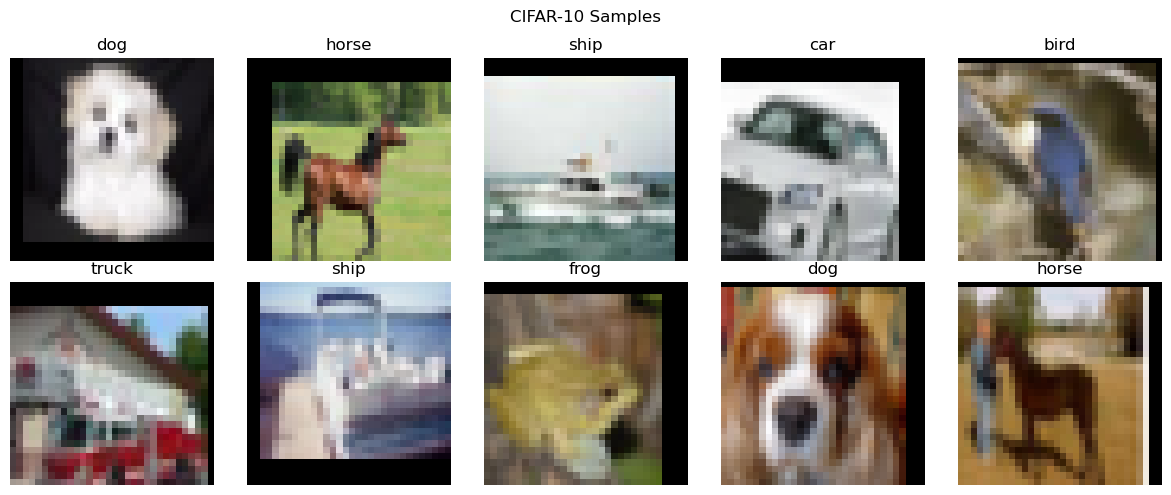

In [ ]:

CIFAR_MEAN, CIFAR_STD = compute_cifar10_stats()
print('Computed from train set (ToTensor only):')
print('  mean:', tuple(round(x, 4) for x in CIFAR_MEAN))
print('  std: ', tuple(round(x, 4) for x in CIFAR_STD))

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

NUM_WORKERS = 0 if os.name == 'nt' else 2
BATCH_SIZE = 256

train_set = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=train_transform)
test_set = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=test_transform)
train_loader_p1 = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader_p1 = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f'Train: {len(train_set)}, Test: {len(test_set)}')

images, labels = next(iter(train_loader_p1))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
mean_t = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_STD).view(3, 1, 1)
for ax, img, lb in zip(axes.ravel(), images[:10], labels[:10]):
    ax.imshow((img * std_t + mean_t).permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(CIFAR10_CLASSES[lb]); ax.axis('off')
plt.suptitle('CIFAR-10 Samples')
plt.tight_layout(); plt.show()

### 1.2 网络结构

采用Pre-Activation残差块（BN→激活→Conv），
三阶段特征提取 + 全局平均池化 + 两层全连接。

In [ ]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2023, 0.1994, 0.2010)

def make_activation(name):
    name = name.lower()
    if name == 'relu':
        return nn.ReLU(inplace=True)
    if name == 'leaky_relu':
        return nn.LeakyReLU(0.1, inplace=True)
    if name == 'gelu':
        return nn.GELU()
    raise ValueError(name)


class PreActBlock(nn.Module):
    """
    Pre-activation 残差块：先 BN/激活，再卷积；可选 stride 下采样。
    """
    def __init__(self, in_ch, out_ch, stride=1, act='relu', dropout=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.act1 = make_activation(act)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act2 = make_activation(act)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if stride != 1 or in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.conv1(self.act1(self.bn1(x)))
        out = self.drop(out)
        out = self.conv2(self.act2(self.bn2(out)))
        return out + self.shortcut(x)


class CIFARCNN(nn.Module):
    def __init__(self, width=48, depth=3, act='relu', dropout=0.4, num_classes=10):
        super().__init__()
        w = width
        self.stem = nn.Sequential(
            nn.Conv2d(3, w, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(w),
            make_activation(act),
        )
        self.stage1 = self._make_stage(w, w, depth, stride=1, act=act, dropout=0.05)
        self.stage2 = self._make_stage(w, w * 2, depth, stride=2, act=act, dropout=0.1)
        self.stage3 = self._make_stage(w * 2, w * 4, depth, stride=2, act=act, dropout=0.1)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(w * 4, 128),
            make_activation(act),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
        self._init_weights(act)

    def _make_stage(self, in_ch, out_ch, n_blocks, stride, act, dropout):
        blocks = [PreActBlock(in_ch, out_ch, stride=stride, act=act, dropout=dropout)]
        for _ in range(n_blocks - 1):
            blocks.append(PreActBlock(out_ch, out_ch, act=act, dropout=dropout))
        blocks.append(nn.MaxPool2d(2))
        return nn.Sequential(*blocks)

    def _init_weights(self, act):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                if act == 'relu':
                    nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                else:
                    nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        return self.head(x)


demo = CIFARCNN(width=48, depth=3).to(device)
print(demo)
print('Params:', f'{count_parameters(demo):,}')

CIFARCNN(
  (stem): Sequential(
    (0): Conv2d(3, 48, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): PreActBlock(
      (bn1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
      (conv2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (drop): Dropout2d(p=0.05, inplace=False)
      (shortcut): Identity()
    )
    (1): PreActBlock(
      (bn1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv1): Conv2d(48, 48, kernel_size=(3, 3

### 1.3 训练

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    total_loss, total_acc, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        if criterion is not None:
            total_loss += criterion(logits, y).item() * x.size(0)
        total_acc += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
    return (total_loss / n if criterion else None), total_acc / n


def fit_cifar(model, train_loader, test_loader, epochs, max_lr=1e-3, optimizer_name='adam',
              weight_decay=5e-4, patience=20, save_path=None, verbose=True, desc='Train'):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=max_lr, momentum=0.9, weight_decay=weight_decay)
    stopper = EarlyStopper(patience=patience)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_state, best_acc = None, 0.0
    first_epoch_state = None
    t0 = time.time()
    epoch_range = tqdm(range(1, epochs + 1), desc=desc) if verbose else range(1, epochs + 1)

    for epoch in epoch_range:
        model.train()
        batch_losses, batch_accs = [], []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            batch_losses.append(loss.item())
            batch_accs.append((logits.argmax(1) == y).float().mean().item())

        tr_loss, tr_acc = np.mean(batch_losses), np.mean(batch_accs)
        te_loss, te_acc = evaluate(model, test_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        improved = stopper.step(te_acc)
        if epoch == 1:
            first_epoch_state = copy.deepcopy(model.state_dict())

        if improved and te_acc > best_acc:
            best_acc = te_acc
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            epoch_range.set_postfix(loss=f'{tr_loss:.3f}', test=f'{te_acc:.3f}', best=f'{best_acc:.3f}')
        if stopper.should_stop:
            if verbose:
                print(f'Early stop at epoch {epoch}, best test acc={best_acc:.4f}')
            break

    if best_state:
        model.load_state_dict(best_state)
    if save_path:
        torch.save({'state_dict': model.state_dict(), 'test_acc': best_acc}, save_path)

    elapsed = time.time() - t0
    _, final_acc = evaluate(model, test_loader)
    return history, best_acc, elapsed, first_epoch_state

### 1.4 主模型训练

In [ ]:
EPOCHS_PART1 = 100  
set_random_seeds(42)
model_p1 = CIFARCNN(width=48, depth=3, act='relu', dropout=0.4).to(device)

history_p1, test_acc_p1, time_p1, early_ckpt = fit_cifar(
    model_p1, train_loader_p1, test_loader_p1,
    epochs=EPOCHS_PART1, max_lr=1e-3, optimizer_name='adam', weight_decay=5e-4,
    save_path=os.path.join(MODELS_DIR, 'cifarcnn_best.pth'),
)
print(f'Params: {count_parameters(model_p1):,} | Best test acc: {test_acc_p1:.4f} | Error: {1-test_acc_p1:.4f}')

Train:   0%|          | 0/40 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 1.5 消融实验（结构 / 激活 / 正则 / 优化器）

- **Epoch=100**
- **Early Stopping (patience=20)**：验证集长期不提升则提前停止，故进度条可能不到 100
- 每组实验保存 **best 权重** 到 `./models/ablation/<组名>/`，并输出训练曲线与对比图

In [ ]:
EPOCHS_ABLATION = 100
EARLY_STOP_PATIENCE = 20

ABLATION_PALETTE = ['#E45756', '#4C78A8', '#F58518', '#72B7B2', '#54A24B', '#B279A2', '#FF9DA6']


def run_ablation(name, save_prefix='misc', **kwargs):
    """单次消融：训练并保存该组 best 权重。"""
    set_random_seeds(42)
    model_kwargs = {k: v for k, v in kwargs.items() if k in ['width', 'depth', 'act', 'dropout']}
    m = CIFARCNN(**model_kwargs).to(device)
    opt = kwargs.get('optimizer', 'adam')
    lr = kwargs.get('max_lr', 1e-3 if opt == 'adam' else 0.05)
    safe_name = name.replace('=', '_').replace(' ', '_').replace('(', '').replace(')', '').replace('.', 'p')
    ckpt_dir = os.path.join(ABLATION_MODELS_DIR, save_prefix)
    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_path = os.path.join(ckpt_dir, f'{safe_name}.pth')
    history, best_acc, elapsed, _ = fit_cifar(
        m, train_loader_p1, test_loader_p1,
        epochs=EPOCHS_ABLATION,
        max_lr=lr,
        optimizer_name=opt,
        weight_decay=kwargs.get('weight_decay', 5e-4),
        patience=EARLY_STOP_PATIENCE,
        verbose=True,
        desc=name,
        save_path=ckpt_path,
    )
    actual_epochs = len(history['test_acc'])
    return {
        'name': name,
        'history': history,
        'params': count_parameters(m),
        'best_acc': best_acc,
        'final_acc': history['test_acc'][-1],
        'epochs_run': actual_epochs,
        'time_min': elapsed / 60,
        'checkpoint': ckpt_path,
    }


def plot_group_curves(results, group_title, save_prefix):
    """
    同组实验包含loss。
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for i, r in enumerate(results):
        c = ABLATION_PALETTE[i % len(ABLATION_PALETTE)]
        h = r['history']
        ep = np.arange(1, len(h['test_acc']) + 1)
        axes[0].plot(ep, h['test_acc'], label=f"{r['name']} (best={r['best_acc']:.3f})", color=c, lw=2)
        axes[1].plot(ep, np.log(np.maximum(h['test_loss'], 1e-8)), label=r['name'], color=c, lw=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy')
    axes[0].set_title(f'{group_title} — Accuracy'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('log(Test Loss)')
    axes[1].set_title(f'{group_title} — Log Loss'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'{save_prefix}_curves.png'), dpi=200, bbox_inches='tight')
    plt.show()


def plot_group_bars(results, group_title, save_prefix):
    """
    同组实验最佳准确率柱状图。
    """
    fig, ax = plt.subplots(figsize=(max(6, len(results) * 1.6), 4.5))
    names = [r['name'] for r in results]
    accs = [r['best_acc'] for r in results]
    colors = [ABLATION_PALETTE[i % len(ABLATION_PALETTE)] for i in range(len(results))]
    bars = ax.bar(names, accs, color=colors, edgecolor='black', linewidth=0.6, width=0.55)
    for bar, r in zip(bars, results):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                f"{h:.3f}\n{r['params']/1e6:.2f}M params\n{r['epochs_run']} ep",
                ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, min(1.05, max(accs) + 0.12))
    ax.set_ylabel('Best Test Accuracy')
    ax.set_title(group_title)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'{save_prefix}_bars.png'), dpi=200, bbox_inches='tight')
    plt.show()


def print_summary_table(results, title):
    print('\n' + '=' * 72)
    print(title)
    print('=' * 72)
    print(f"{'Config':<18} {'Best Acc':>9} {'Final Acc':>10} {'Epochs':>7} {'Params':>10} {'Time(min)':>10}")
    print('-' * 72)
    for r in results:
        print(f"{r['name']:<18} {r['best_acc']:>9.4f} {r['final_acc']:>10.4f} {r['epochs_run']:>7} {r['params']:>10,} {r['time_min']:>10.1f}")
    print('=' * 72)


def run_ablation_group(title, configs, save_prefix):
    results = [run_ablation(n, save_prefix=save_prefix, **cfg) for n, cfg in configs]
    print_summary_table(results, title)
    for r in results:
        print(f"  saved: {r['checkpoint']}")
    plot_group_curves(results, title, save_prefix)
    plot_group_bars(results, title, save_prefix)
    return results


# 1) Try different number of neurons/filters
res_structure = run_ablation_group(
    'Ablation: Network Width (filters)',
    [
        ('width=32', dict(width=32, depth=3, act='relu')),
        ('width=48', dict(width=48, depth=3, act='relu')),
        ('width=64', dict(width=64, depth=3, act='relu')),
    ],
    'ablation_structure',
)

# Try different activations
res_activation = run_ablation_group(
    'Ablation: Activation Functions',
    [
        ('ReLU', dict(width=48, depth=3, act='relu')),
        ('LeakyReLU', dict(width=48, depth=3, act='leaky_relu')),
        ('GELU', dict(width=48, depth=3, act='gelu')),
    ],
    'ablation_activation',
)

# Try different loss functions (with different regularization)
res_weight_decay = run_ablation_group(
    'Ablation: L2 Regularization (weight_decay)',
    [
        ('wd=0', dict(width=48, depth=3, act='relu', weight_decay=0)),
        ('wd=1e-4', dict(width=48, depth=3, act='relu', weight_decay=1e-4)),
        ('wd=5e-4', dict(width=48, depth=3, act='relu', weight_decay=5e-4)),
        ('wd=5e-3', dict(width=48, depth=3, act='relu', weight_decay=5e-3)),
    ],
    'ablation_weight_decay',
)

# Try different optimizers using torch.optim
res_optimizer = run_ablation_group(
    'Ablation: Optimizers',
    [
        ('Adam (lr=1e-3)', dict(width=48, depth=3, act='relu', optimizer='adam', max_lr=1e-3)),
        ('SGD (lr=0.05)', dict(width=48, depth=3, act='relu', optimizer='sgd', max_lr=0.05)),
    ],
    'ablation_optimizer',
)

ablation_results = res_structure + res_activation + res_weight_decay + res_optimizer

# Plot all
print_summary_table(ablation_results, 'All Ablation Experiments — Summary')

fig, ax = plt.subplots(figsize=(14, 5))
names = [r['name'] for r in ablation_results]
accs = [r['best_acc'] for r in ablation_results]
colors = [ABLATION_PALETTE[i % len(ABLATION_PALETTE)] for i in range(len(ablation_results))]
bars = ax.barh(names, accs, color=colors, edgecolor='black', linewidth=0.5, height=0.65)
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.003, bar.get_y() + bar.get_height() / 2, f'{acc:.4f}', va='center', fontsize=9)
ax.set_xlim(0, 1.0)
ax.set_xlabel('Best Test Accuracy')
ax.set_title('All Ablation Experiments (epochs≤100, early stop patience=20)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ablation_overview.png'), dpi=200, bbox_inches='tight')
plt.show()

### 1.6 可视化：曲线、卷积核、Loss Landscape

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_p1['train_loss'], label='Train')
axes[0].plot(history_p1['test_loss'], label='Test')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_p1['train_acc'], label='Train')
axes[1].plot(history_p1['test_acc'], label='Test')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'part1_curves.png')); plt.show()

# 对数损失
plt.figure(figsize=(6, 4))
plt.plot(np.log(history_p1['train_loss']), label='Train')
plt.plot(np.log(history_p1['test_loss']), label='Test')
plt.xlabel('Epoch'); plt.ylabel('log(loss)'); plt.title('Log Loss Curve'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'part1_log_loss.png')); plt.show()


def plot_first_layer_filters(model, n_show=16):
    w = model.stem[0].weight.data.cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.ravel()):
        if i < min(n_show, w.shape[0]):
            f = w[i].mean(axis=0)
            f = (f - f.min()) / (f.max() - f.min() + 1e-8)
            ax.imshow(f, cmap='gray')
        ax.axis('off')
    plt.suptitle('Stem Conv Filters (channel-mean grayscale)')
    plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'part1_filters.png')); plt.show()

plot_first_layer_filters(model_p1)


def _set_params_from_vector(model, vector):
    off = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(vector[off:off + n].view_as(p))
        off += n


def _batch_loss(model, loader, criterion):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    with torch.no_grad():
        return criterion(model(x), y).item()


def interpolate_loss_1d(model, loader, state_a, state_b, steps=25):
    """两个 checkpoint 之间一维线性插值：alpha -> loss。"""
    vec_a = torch.cat([v.view(-1) for v in state_a.values()])
    vec_b = torch.cat([v.view(-1) for v in state_b.values()])
    alphas = np.linspace(0, 1, steps)
    criterion = nn.CrossEntropyLoss()
    backup = copy.deepcopy(model.state_dict())
    losses = []
    for a in alphas:
        mixed = (1 - a) * vec_a + a * vec_b
        off = 0
        tmp = {}
        for k, v in state_a.items():
            n = v.numel()
            tmp[k] = mixed[off:off + n].view_as(v)
            off += n
        model.load_state_dict(tmp, strict=False)
        losses.append(_batch_loss(model, loader, criterion))
    model.load_state_dict(backup)

    plt.figure(figsize=(6, 4))
    plt.plot(alphas, losses, 'o-')
    plt.xlabel('Interpolation alpha'); plt.ylabel('Loss')
    plt.title('1D Loss Landscape (weight interpolation)')
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(FIGURES_DIR, 'part1_loss_landscape_1d.png'), dpi=200, bbox_inches='tight')
    plt.show()


def plot_loss_landscape_3d(model, loader, steps=21, scale=1.0, seed=42):
    """
    2D 平面（alpha, beta 两个方向）上的 loss 地形，用 3D 曲面展示：Z = Loss。
    在高维权重空间里取训练好的点为原点，沿两个正交随机方向扰动。
    """
    criterion = nn.CrossEntropyLoss()
    backup = copy.deepcopy(model.state_dict())
    base = torch.cat([p.data.view(-1) for p in model.parameters()]).to(device)

    g = torch.Generator(device='cpu')
    g.manual_seed(seed)
    dir_x = torch.randn(base.numel(), generator=g).to(device)
    dir_x = dir_x / (dir_x.norm() + 1e-10)
    dir_y = torch.randn(base.numel(), generator=g).to(device)
    dir_y = dir_y - torch.dot(dir_y, dir_x) * dir_x
    dir_y = dir_y / (dir_y.norm() + 1e-10)

    alphas = np.linspace(-scale, scale, steps)
    betas = np.linspace(-scale, scale, steps)
    losses = np.zeros((steps, steps))
    for i, a in enumerate(tqdm(alphas, desc='Loss landscape 3D', leave=False)):
        for j, b in enumerate(betas):
            _set_params_from_vector(model, base + a * dir_x + b * dir_y)
            losses[i, j] = _batch_loss(model, loader, criterion)

    model.load_state_dict(backup)

    X, Y = np.meshgrid(alphas, betas)
    Z = losses.T
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', linewidth=0.2, antialiased=True)
    ax.set_xlabel('Alpha (Direction X)')
    ax.set_ylabel('Beta (Direction Y)')
    ax.set_zlabel('Loss')
    ax.set_title('2D Loss Landscape (3D surface)')
    fig.colorbar(surf, shrink=0.55, aspect=12, label='Loss')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'part1_loss_landscape_3d.png'), dpi=200, bbox_inches='tight')
    plt.show()


if early_ckpt is not None:
    interpolate_loss_1d(model_p1, test_loader_p1, early_ckpt, model_p1.state_dict())

plot_loss_landscape_3d(model_p1, test_loader_p1, steps=21, scale=1.0, seed=42)

---
# Part 2: Batch Normalization

### 2.1 VGG 数据加载

In [ ]:
class PartialDataset(Dataset):
    def __init__(self, dataset, n_items):
        self.dataset = dataset; self.n_items = n_items
    def __getitem__(self, idx):
        return self.dataset[idx % len(self.dataset)]
    def __len__(self):
        return min(self.n_items, len(self.dataset))


def get_vgg_loaders(batch_size=128, n_items=-1):
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    tr = datasets.CIFAR10(DATA_ROOT, train=True, download=True, transform=train_tf)
    te = datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=test_tf)
    if n_items > 0:
        tr = PartialDataset(tr, n_items)
    return (
        DataLoader(tr, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS),
        DataLoader(te, batch_size=100, shuffle=False, num_workers=NUM_WORKERS),
    )

N_ITEMS = -1  
train_loader_p2, val_loader_p2 = get_vgg_loaders(n_items=N_ITEMS)
print('VGG train batches:', len(train_loader_p2))

### 2.2 VGG-A 与 VGG-A_BatchNorm

BN仅加在每个Conv之后，不在FC层。

In [ ]:
def init_weights_(m):
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None: nn.init.zeros_(m.bias)


class VGG_A(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, num_classes),
        )
        self.apply(init_weights_)

    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))


class VGG_A_BatchNorm(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def cblock(i, o, pool=False):
            seq = [nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(True)]
            if pool: seq.append(nn.MaxPool2d(2))
            return seq

        layers = []
        layers += cblock(3, 64, True)
        layers += cblock(64, 128, True)
        layers += cblock(128, 256)
        layers += cblock(256, 256, True)
        layers += cblock(256, 512)
        layers += cblock(512, 512, True)
        layers += cblock(512, 512)
        layers += cblock(512, 512, True)
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, num_classes),
        )
        self.apply(init_weights_)

    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))


print('VGG_A:', count_parameters(VGG_A()))
print('VGG_A_BN:', count_parameters(VGG_A_BatchNorm()))

### 2.3 VGG 训练（记录逐步 loss）

In [ ]:
def vgg_accuracy(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += model(x).argmax(1).eq(y).sum().item(); total += y.size(0)
    return 100.0 * correct / total


def train_vgg(model, optimizer, train_loader, val_loader, epochs=20):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    step_losses, epoch_losses, val_accs = [], [], []
    best_acc, best_state = 0.0, None

    for epoch in tqdm(range(epochs), desc='VGG'):
        model.train(); batch_losses = []; run = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            batch_losses.append(loss.item())
            run += loss.item()
            loss.backward(); optimizer.step()
        step_losses.append(batch_losses)
        epoch_losses.append(run / len(train_loader))
        acc = vgg_accuracy(model, val_loader)
        val_accs.append(acc)
        if acc > best_acc:
            best_acc = acc; best_state = copy.deepcopy(model.state_dict())
        print(f'Epoch {epoch+1}: loss={epoch_losses[-1]:.4f}, val_acc={acc:.2f}%')

    if best_state: model.load_state_dict(best_state)
    return {'step_losses': step_losses, 'epoch_losses': epoch_losses, 'val_accs': val_accs, 'best_acc': best_acc}

### 2.4 VGG-A vs VGG-A+BN 对比训练

In [ ]:
EPOCHS_VGG = 20
LR_VGG = 1e-3

set_random_seeds(2020)
model_no_bn = VGG_A().to(device)
res_no_bn = train_vgg(model_no_bn, optim.Adam(model_no_bn.parameters(), lr=LR_VGG),
                      train_loader_p2, val_loader_p2, epochs=EPOCHS_VGG)
torch.save(model_no_bn.state_dict(), os.path.join(MODELS_DIR, 'vgg_a_no_bn.pth'))

set_random_seeds(2020)
model_bn = VGG_A_BatchNorm().to(device)
res_bn = train_vgg(model_bn, optim.Adam(model_bn.parameters(), lr=LR_VGG),
                   train_loader_p2, val_loader_p2, epochs=EPOCHS_VGG)
torch.save(model_bn.state_dict(), os.path.join(MODELS_DIR, 'vgg_a_bn.pth'))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(res_no_bn['epoch_losses'], label='VGG-A')
ax[0].plot(res_bn['epoch_losses'], label='VGG-A+BN'); ax[0].set_title('Train Loss'); ax[0].legend()
ax[1].plot(res_no_bn['val_accs'], label='VGG-A')
ax[1].plot(res_bn['val_accs'], label='VGG-A+BN'); ax[1].set_title('Val Accuracy (%)'); ax[1].legend()
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'vgg_bn_compare.png')); plt.show()

### 2.5 Loss Landscape（多学习率 min-max 带）

按作业要求：用 `[2e-3, 1e-3, 5e-4, 1e-4]` 训练多个模型，同一步取 loss 最大/最小值，`fill_between` 对比。

In [ ]:
LEARNING_RATES = [2e-3, 1e-3, 5e-4, 1e-4]
EPOCHS_LANDSCAPE = 20
INITIAL_SKIP = 25
PLOT_DENSITY = 1


def train_vgg_multi_lr(model_cls, tag, lrs, epochs, seed=2020):
    all_step_losses = []
    for lr in lrs:
        set_random_seeds(seed)
        m = model_cls().to(device)
        out = train_vgg(m, optim.Adam(m.parameters(), lr=lr), train_loader_p2, val_loader_p2, epochs=epochs)
        flat = [v for ep in out['step_losses'] for v in ep]
        all_step_losses.append(flat)
        np.savetxt(os.path.join(VGG_RESULTS_DIR, f'{tag}_lr_{lr}.txt'), flat, fmt='%.6f')
        print(f'{tag} lr={lr}: best val acc={out["best_acc"]:.2f}%')
    return all_step_losses


def loss_min_max_band(all_step_losses):
    min_len = min(len(x) for x in all_step_losses)
    mins, maxs = [], []
    for t in range(min_len):
        vals = [all_step_losses[i][t] for i in range(len(all_step_losses))]
        mins.append(min(vals)); maxs.append(max(vals))
    return np.array(mins), np.array(maxs)


print('Training vanilla VGG...')
vanilla_losses = train_vgg_multi_lr(VGG_A, 'vanilla_vgg', LEARNING_RATES, EPOCHS_LANDSCAPE)
print('Training VGG+BN...')
bn_losses = train_vgg_multi_lr(VGG_A_BatchNorm, 'norm_vgg', LEARNING_RATES, EPOCHS_LANDSCAPE)

v_min, v_max = loss_min_max_band(vanilla_losses)
b_min, b_max = loss_min_max_band(bn_losses)
v_min, v_max = v_min[INITIAL_SKIP::PLOT_DENSITY], v_max[INITIAL_SKIP::PLOT_DENSITY]
b_min, b_max = b_min[INITIAL_SKIP::PLOT_DENSITY], b_max[INITIAL_SKIP::PLOT_DENSITY]
steps = np.arange(len(v_min))

plt.figure(figsize=(12, 6))
plt.fill_between(steps, v_min, v_max, alpha=0.45, color='#EC0D0D', label='VGG-A (no BN)')
plt.fill_between(steps, b_min, b_max, alpha=0.45, color='#0B31EA', label='VGG-A + BN')
plt.xlabel('Training Step'); plt.ylabel('Loss')
plt.title(f'Loss Landscape Band (LRs={LEARNING_RATES}, skip={INITIAL_SKIP})')
plt.legend(); plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'loss_landscape_band.png'))
plt.show()
print(f'Band width mean — no BN: {(v_max-v_min).mean():.4f}, with BN: {(b_max-b_min).mean():.4f}')

### 2.6 梯度可预测性分析

In [ ]:
def flat_grad(model, loader, criterion, n_batches=15):
    model.train(); losses = []
    for i, (x, y) in enumerate(loader):
        if i >= n_batches: break
        x, y = x.to(device), y.to(device)
        model.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        losses.append(loss.item())
    g = torch.cat([(p.grad if p.grad is not None else torch.zeros_like(p)).view(-1) for p in model.parameters()])
    return np.mean(losses), g


def grad_sensitivity(model_cls, alphas=np.linspace(-0.8, 0.8, 17)):
    set_random_seeds(2020)
    m = model_cls().to(device)
    train_vgg(m, optim.Adam(m.parameters(), lr=1e-3), train_loader_p2, val_loader_p2, epochs=1)
    crit = nn.CrossEntropyLoss()
    base_loss, base_g = flat_grad(m, train_loader_p2, crit)
    base_w = torch.cat([p.data.view(-1) for p in m.parameters()])
    unit = base_g / (base_g.norm() + 1e-12)
    loss_curve, grad_delta = [], []
    for a in alphas:
        off = 0
        for p in m.parameters():
            n = p.numel(); p.data.copy_((base_w[off:off+n] + a * unit[off:off+n]).view_as(p)); off += n
        l, g = flat_grad(m, train_loader_p2, crit)
        loss_curve.append(l); grad_delta.append((g - base_g).norm().item())
    return alphas, loss_curve, grad_delta

a1, l1, g1 = grad_sensitivity(VGG_A)
a2, l2, g2 = grad_sensitivity(VGG_A_BatchNorm)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(a1, l1, 'o-', label='no BN'); ax[0].plot(a2, l2, 'o-', label='with BN')
ax[0].axvline(0, ls='--', c='gray', alpha=0.5); ax[0].set_title('Loss along gradient'); ax[0].legend()
ax[1].plot(a1, g1, 'o-', label='no BN'); ax[1].plot(a2, g2, 'o-', label='with BN')
ax[1].axvline(0, ls='--', c='gray', alpha=0.5); ax[1].set_title('Gradient change ||Δg||'); ax[1].legend()
for x in ax: x.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'gradient_sensitivity.png')); plt.show()

### 2.7 总结

In [ ]:
print('=' * 55)
print('[Part 1] CIFARCNN — PreAct residual, 100-epoch training + ablations')
print(f'  Params: {count_parameters(model_p1):,}')
print(f'  Best test acc: {test_acc_p1:.4f} (error {1-test_acc_p1:.4f})')
print('[Part 2] VGG-A vs VGG-A+BN')
print(f'  No BN best: {res_no_bn["best_acc"]:.2f}% | With BN best: {res_bn["best_acc"]:.2f}%')
print(f'  Loss band width — no BN: {(v_max-v_min).mean():.4f}, BN: {(b_max-b_min).mean():.4f}')
print(f'  Figures -> {FIGURES_DIR} | VGG logs -> {VGG_RESULTS_DIR}')